Alumna: Rojas, Paola

Materia: Aprendizaje Automatico

Clase N°5 - Árbol de Decisión -
K-Nearest Neighbors (K-NN)

En este trabajo práctico se utilizará el dataset usuarios_win_mac_lin.csv para aplicar técnicas de clasificación mediante algoritmos de Machine Learning.

El objetivo es predecir qué sistema operativo utiliza un usuario según su comportamiento dentro de un sitio web.
Donde: 0 = Windows
1 = Macintosh
2 = Linux

In [2]:
# IMPORTAMOS LIBRERÍAS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from matplotlib.colors import ListedColormap
import seaborn as sns

In [3]:
# SUBIMOS EL ARCHIVO
from google.colab import files
files.upload()

# CARGAMOS EL DATASET
df = pd.read_csv("usuarios_win_mac_lin.csv")

# MOSTRAMOS LAS PRIMERAS FILAS
print(df.head())


Saving usuarios_win_mac_lin.csv to usuarios_win_mac_lin.csv
   duracion  paginas  acciones  valor  clase
0       7.0        2         4      8      2
1      21.0        2         6      6      2
2      57.0        2         4      4      2
3     101.0        3         6     12      2
4     109.0        2         6     12      2


In [4]:
# VARIABLES DE ENTRADA Y SALIDA

# Variables de entrada
X = df[["duracion", "paginas", "acciones", "valor"]]

# Variable de salida
Y = df["clase"]

# DIVISIÓN DE DATOS: 80% entrenamiento 20% prueba

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# NORMALIZACIÓN DE DATOS
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [5]:
# Modelo K-Nearest Neighbors (KNN)
knn = KNeighborsClassifier(n_neighbors=13, weights='distance')


knn.fit(X_train_scaled, y_train) # Entrenamiento
predicciones_knn = knn.predict(X_test_scaled) # Predicciones

# Métricas
print()
print("Métricas K-NN:")
print(classification_report(y_test, predicciones_knn))

# Precisión
accuracy_knn = accuracy_score(y_test, predicciones_knn)

print()
print("Precisión K-NN:")
print(accuracy_knn)


Métricas K-NN:
              precision    recall  f1-score   support

           0       0.72      0.81      0.76        16
           1       0.73      0.67      0.70        12
           2       1.00      0.83      0.91         6

    accuracy                           0.76        34
   macro avg       0.82      0.77      0.79        34
weighted avg       0.77      0.76      0.77        34


Precisión K-NN:
0.7647058823529411


In [6]:
# Modelo Arbol de Decisión

tree = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
tree.fit(X_train_scaled, y_train) # Entrenamiento
y_pred_tree = tree.predict(X_test_scaled) # Predicciones

# Métricas
print()
print("Métricas Árbol de Decisión:")
print(classification_report(y_test, y_pred_tree))

# Precisión
accuracy_arbol = accuracy_score(y_test, y_pred_tree)

print()
print("Precisión Árbol de Decisión:")
print(accuracy_arbol)


Métricas Árbol de Decisión:
              precision    recall  f1-score   support

           0       0.62      0.94      0.75        16
           1       0.80      0.33      0.47        12
           2       1.00      0.83      0.91         6

    accuracy                           0.71        34
   macro avg       0.81      0.70      0.71        34
weighted avg       0.75      0.71      0.68        34


Precisión Árbol de Decisión:
0.7058823529411765



Accuracy KNN: 0.7647058823529411
Accuracy Árbol: 0.7058823529411765


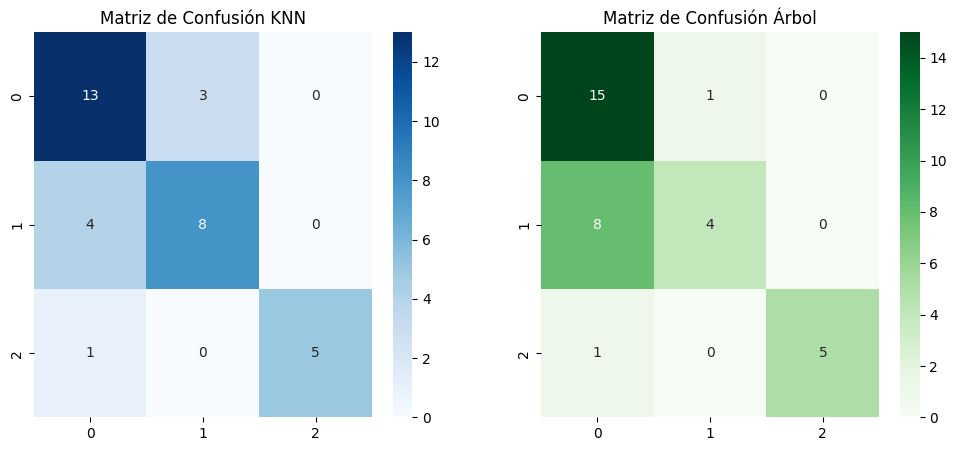

In [7]:
# COMPARACIÓN DE MODELOS

print()
print("Accuracy KNN:", accuracy_score(y_test, predicciones_knn))
print("Accuracy Árbol:", accuracy_score(y_test, y_pred_tree))


# MATRICES DE CONFUSIÓN

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, predicciones_knn), annot=True, fmt="d", ax=ax[0], cmap="Blues")
ax[0].set_title("Matriz de Confusión KNN")

sns.heatmap(confusion_matrix(y_test, y_pred_tree), annot=True, fmt="d", ax=ax[1], cmap="Greens")
ax[1].set_title("Matriz de Confusión Árbol")
plt.show()

En este trabajo usamos dos modelos de Machine Learning: K-NN y Árbol de Decisión, para predecir qué sistema operativo usa un usuario.

El modelo K-NN obtuvo una precisión de 0.76, mientras que el Árbol de Decisión obtuvo 0.71.

Esto significa que el modelo K-NN logró acertar más veces en las predicciones.

También se puede observar que K-NN tuvo resultados más equilibrados en las métricas generales, especialmente en las clases Windows y Macintosh. En cambio, el Árbol de Decisión tuvo más dificultad para reconocer correctamente algunos casos de la clase Macintosh.

Por otro lado, ambos modelos tuvieron muy buenos resultados en la clase Linux.


En general, el modelo K-NN fue el que mejor funcionó con este conjunto de datos, ya que obtuvo una mayor precisión y mejores resultados en las métricas.

Gracias a esta actividad pudimos comparar dos algoritmos distintos y entender cómo cada modelo puede comportarse de manera diferente frente al mismo problema de clasificación.